In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm


--- Payment Type Distribution ---
primary_payment_type  order_count  total_value  median_order_value  mean_order_value  pct_orders  pct_value
         credit_card        74391  12431881.69              109.50        167.115400   75.394501  78.389550
              boleto        19636   2837678.01               93.82        144.514056   19.900881  17.893052
             voucher         3121    372115.45               82.72        119.229558    3.163101   2.346384
          debit_card         1521    217430.64               89.58        142.952426    1.541518   1.371015

ANOVA (CC vs Boleto Order Value): F-stat=161.37, p-value=6.1025e-37
Spearman Correlation (Installments vs Order Value for CC): rho=0.461, p-value=0.0000e+00


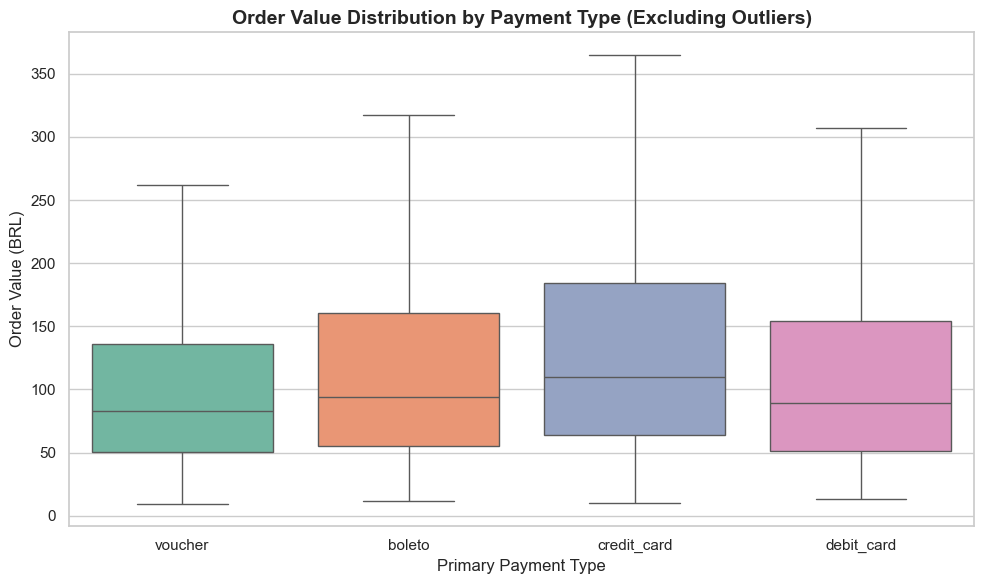

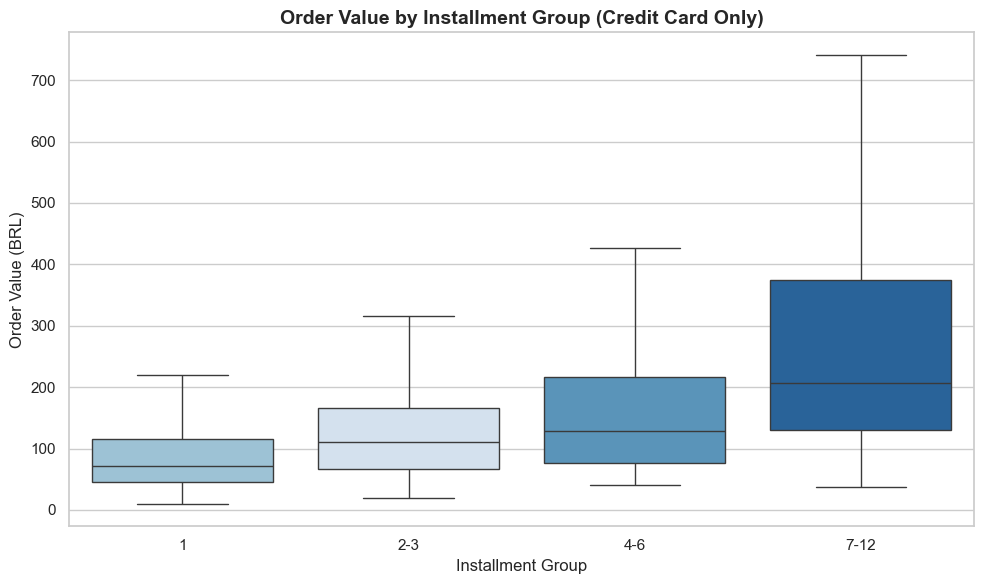

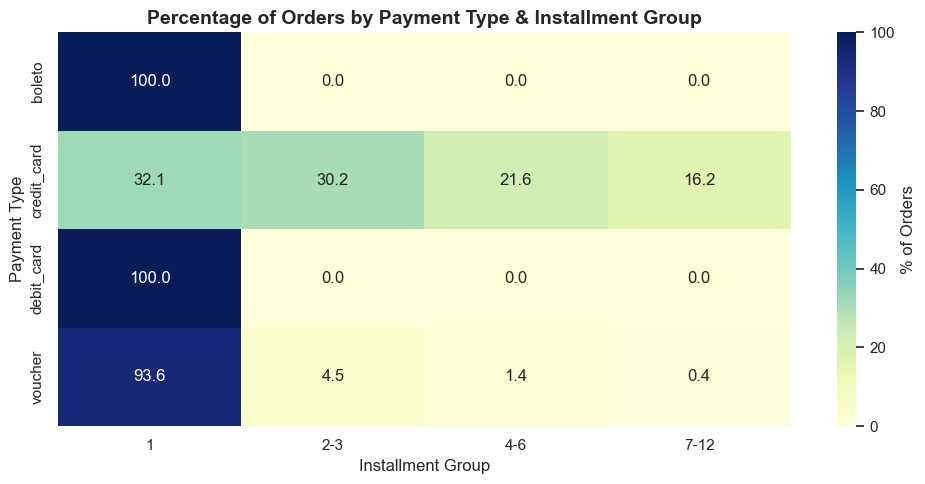

In [9]:
# ==========================================
# 1. DATA LOADING
# ==========================================
datasetPath = "dataset/" 
datasetsCSV = {
    "customers": datasetPath + "olist_customers_dataset.csv",
    "orders": datasetPath + "olist_orders_dataset.csv",
    "orderItems": datasetPath + "olist_order_items_dataset.csv",
    "orderPayments": datasetPath + "olist_order_payments_dataset.csv",
    "orderReviews": datasetPath + "olist_order_reviews_dataset.csv",
    "products": datasetPath + "olist_products_dataset.csv",
    "productCategoryTranslation": datasetPath + "product_category_name_translation.csv"
}

customers = pd.read_csv(datasetsCSV["customers"])
orders = pd.read_csv(datasetsCSV["orders"])
items = pd.read_csv(datasetsCSV["orderItems"])
payments = pd.read_csv(datasetsCSV["orderPayments"])
reviews = pd.read_csv(datasetsCSV["orderReviews"])

# ==========================================
# 2. BUILD THE CORE PAYMENT DATASET (ORDER LEVEL)
# ==========================================

# A. Payment Aggregations
# Identify the primary payment method (the one with the highest value for the order)
idx_max_payment = payments.groupby('order_id')['payment_value'].idxmax()
primary_payment = payments.loc[idx_max_payment, ['order_id', 'payment_type']].rename(
    columns={'payment_type': 'primary_payment_type'}
)

payment_stats = payments.groupby('order_id').agg(
    total_payment_value=('payment_value', 'sum'),
    max_installments=('payment_installments', 'max'),
    payment_methods_count=('payment_sequential', 'max')
).reset_index()

payment_order_lvl = pd.merge(payment_stats, primary_payment, on='order_id', how='left')

# B. Item & Value Aggregations
item_stats = items.groupby('order_id').agg(
    total_product_value=('price', 'sum'),
    total_freight_value=('freight_value', 'sum'),
    number_of_items=('order_item_id', 'max'),
    number_of_sellers=('seller_id', 'nunique')
).reset_index()

# C. Review Aggregations
review_stats = reviews.groupby('order_id').agg(
    avg_review_score=('review_score', 'mean')
).reset_index()

# D. Merge Core Dataset
df = orders[['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 
             'order_delivered_customer_date', 'order_estimated_delivery_date']].copy()

df = df.merge(payment_order_lvl, on='order_id', how='inner')
df = df.merge(item_stats, on='order_id', how='left')
df = df.merge(review_stats, on='order_id', how='left')
df = df.merge(customers[['customer_id', 'customer_unique_id', 'customer_state']], on='customer_id', how='left')

# E. Feature Engineering
# Dates
for col in ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']:
    df[col] = pd.to_datetime(df[col])

# Delivery metrics
df['delivery_duration_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['delivery_delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['late_delivery'] = (df['delivery_delay_days'] > 0).astype(float)

# Payment Groups
df['is_installment_payment'] = (df['max_installments'] > 1).astype(int)

def assign_installment_group(x):
    if pd.isna(x) or x <= 1:
        return '1'
    elif 2 <= x <= 3:
        return '2-3'
    elif 4 <= x <= 6:
        return '4-6'
    else:
        return '7-12'

df['installment_group'] = df['max_installments'].apply(assign_installment_group)

# Clean missing values for statistical modeling
df_clean = df.dropna(subset=['total_payment_value', 'primary_payment_type', 'avg_review_score']).copy()
df_clean = df_clean[df_clean['total_payment_value'] > 0] # Remove zero-value anomalies

# ==========================================
# 3. PAYMENT TYPE DISTRIBUTION & ECONOMICS
# ==========================================
print("\n--- Payment Type Distribution ---")
pay_dist = df_clean.groupby('primary_payment_type').agg(
    order_count=('order_id', 'count'),
    total_value=('total_payment_value', 'sum'),
    median_order_value=('total_payment_value', 'median'),
    mean_order_value=('total_payment_value', 'mean')
).reset_index()

pay_dist['pct_orders'] = (pay_dist['order_count'] / pay_dist['order_count'].sum()) * 100
pay_dist['pct_value'] = (pay_dist['total_value'] / pay_dist['total_value'].sum()) * 100
print(pay_dist.sort_values('pct_orders', ascending=False).to_string(index=False))

# ==========================================
# 4. STATISTICAL VALIDATION (ANOVA & Spearman)
# ==========================================
cc_values = df_clean[df_clean['primary_payment_type'] == 'credit_card']['total_payment_value']
boleto_values = df_clean[df_clean['primary_payment_type'] == 'boleto']['total_payment_value']

f_stat, p_val_anova = stats.f_oneway(cc_values, boleto_values)
print(f"\nANOVA (CC vs Boleto Order Value): F-stat={f_stat:.2f}, p-value={p_val_anova:.4e}")

spearman_corr, p_val_spearman = stats.spearmanr(
    df_clean[df_clean['primary_payment_type'] == 'credit_card']['max_installments'], 
    cc_values
)
print(f"Spearman Correlation (Installments vs Order Value for CC): rho={spearman_corr:.3f}, p-value={p_val_spearman:.4e}")

# ==========================================
# 5. OLS REGRESSION (Explaining Order Value)
# ==========================================
model_df = df_clean.dropna(subset=['late_delivery']).copy()
model_df['log_order_value'] = np.log(model_df['total_payment_value'])
model_df['is_credit_card'] = (model_df['primary_payment_type'] == 'credit_card').astype(int)

X = model_df[['max_installments', 'is_credit_card', 'late_delivery', 'number_of_items']]
X = sm.add_constant(X)
y = model_df['log_order_value']

# ==========================================
# 6. VISUALIZATIONS (Updated for Seaborn v0.14.0+)
# ==========================================
sns.set_theme(style="whitegrid")

# Plot 1: Order Value Distribution by Payment Type
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_clean, 
    x='primary_payment_type', 
    y='total_payment_value',
    hue='primary_payment_type', # Added to resolve Future Warning
    legend=False,               # Added to resolve Future Warning
    showfliers=False,
    palette='Set2'
)
plt.title('Order Value Distribution by Payment Type (Excluding Outliers)', fontsize=14, fontweight='bold')
plt.xlabel('Primary Payment Type', fontsize=12)
plt.ylabel('Order Value (BRL)', fontsize=12)
plt.tight_layout()
plt.savefig('payment_type_boxplot.png', dpi=300)
plt.show()

# Plot 2: Order Value by Installment Group (Credit Card Only)
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_clean[df_clean['primary_payment_type'] == 'credit_card'], 
    x='installment_group', 
    y='total_payment_value',
    hue='installment_group',    # Added to resolve Future Warning
    legend=False,               # Added to resolve Future Warning
    order=['1', '2-3', '4-6', '7-12'],
    showfliers=False,
    palette='Blues'
)
plt.title('Order Value by Installment Group (Credit Card Only)', fontsize=14, fontweight='bold')
plt.xlabel('Installment Group', fontsize=12)
plt.ylabel('Order Value (BRL)', fontsize=12)
plt.tight_layout()
plt.savefig('installment_value_boxplot.png', dpi=300)
plt.show()

# Plot 3: Heatmap of Payment Type vs Installment Groups
plt.figure(figsize=(10, 5))
heatmap_data = pd.crosstab(
    df_clean['primary_payment_type'], 
    df_clean['installment_group'], 
    normalize='index'
) * 100

sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': '% of Orders'})
plt.title('Percentage of Orders by Payment Type & Installment Group', fontsize=14, fontweight='bold')
plt.xlabel('Installment Group', fontsize=12)
plt.ylabel('Payment Type', fontsize=12)
plt.tight_layout()
plt.savefig('payment_installment_heatmap.png', dpi=300)
plt.show()